In [68]:
import numpy as np
from numpy.linalg import solve, det, inv, eig, norm

A = np.array([1, 2, 3, 0, -4, 1, 0, 3, -1]).reshape(3, 3)
print(det(A))

b = np.array([2, 2, 1])
print(solve(A, b))

print(np.array_equal(A.T, inv(A)))
# so it's not orthogonal

print(eig(A))
# so the eigenvalues are  1, -4.79128785 and -0.20871215

1.0
[ 38.  -3. -10.]
False
EigResult(eigenvalues=array([ 1.        , -4.79128785, -0.20871215]), eigenvectors=array([[ 1.        , -0.05055961,  0.94256676],
       [ 0.        , -0.78318743, -0.08518794],
       [ 0.        ,  0.6197267 , -0.32297201]]))


In [69]:
from numpy import sin, cos, degrees
def E(ad, bd, gd):
    a = np.radians(ad)
    b = np.radians(bd)
    g = np.radians(gd)
    Ex = np.array([[1, 0, 0], [0, cos(a), sin(a)], [0, -sin(a), cos(a)]])
    Ey = np.array([[cos(b), 0, -sin(b)], [0, 1, 0], [sin(b), 0, cos(b)]])
    Ez1 = np.array([[cos(g), sin(g), 0], [-sin(g), cos(g), 0], [0, 0, 1]])
    Ez2 = np.array([[cos(a), sin(a), 0], [-sin(a), cos(a), 0], [0, 0, 1]])
    return Ez1 @ Ey @ Ez2

E = E(192.25, 90 - 27.4, 180 - 123)
print(E)
print(inv(E))
print(E.T)
print(det(E))

print(eig(E))

[[-0.06698874 -0.87275577 -0.48353891]
 [ 0.49272847 -0.45034696  0.74458463]
 [-0.86760081 -0.1883746   0.46019978]]
[[-0.06698874  0.49272847 -0.86760081]
 [-0.87275577 -0.45034696 -0.1883746 ]
 [-0.48353891  0.74458463  0.46019978]]
[[-0.06698874  0.49272847 -0.86760081]
 [-0.87275577 -0.45034696 -0.1883746 ]
 [-0.48353891  0.74458463  0.46019978]]
1.0
EigResult(eigenvalues=array([-0.52856796+0.84889099j, -0.52856796-0.84889099j,
        1.        +0.j        ]), eigenvectors=array([[ 0.09023842+0.58384315j,  0.09023842-0.58384315j,
        -0.54951651+0.j        ],
       [ 0.68877691+0.j        ,  0.68877691-0.j        ,
         0.22621391+0.j        ],
       [-0.13207344+0.39890747j, -0.13207344-0.39890747j,
         0.80427537+0.j        ]]))


In [3]:
def r(a, d):
    a = np.radians(a)
    d = np.radians(d)
    return np.array([[cos(d) * cos(a)], [cos(d) * sin(a)], [sin(d)]])

v = r(192.25, 27.4) # eq 7.16
print(v, norm(v))
print(E @ v) # the x and y components are so small it's essentially just a rounding error

[[-0.86760081]
 [-0.1883746 ]
 [ 0.46019978]] 1.0
[[2.77555756e-17]
 [5.55111512e-17]
 [1.00000000e+00]]


coef = [ 2.18582332e+02 -5.51003146e+02  5.65812237e+02 -3.13633556e+02
  1.04544074e+02 -2.19331360e+01  2.91867715e+00 -2.39059756e-01
  1.09925609e-02 -2.17117476e-04]


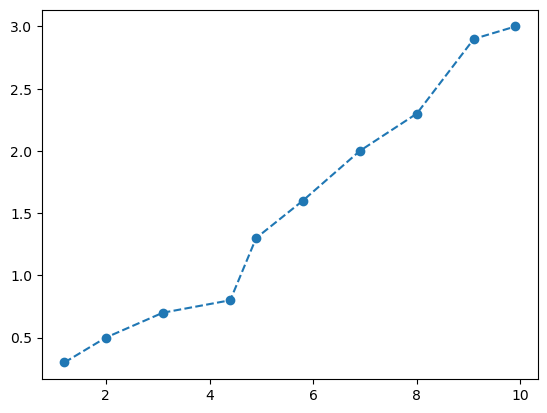

In [70]:
# session quiz 7.5
import matplotlib.pyplot as plt
x = np.array([1.2, 2.0, 3.1, 4.4, 4.9, 5.8, 6.9, 8.0, 9.1, 9.9])
y = np.array([0.3, 0.5, 0.7, 0.8, 1.3, 1.6, 2.0, 2.3, 2.9, 3.0])

# coefficient determining
A = []
for i in range(len(x)):
    for j in range(len(y)):
        A.append(x[i]**j)
A = np.array(A)
A = A.reshape(len(x), len(y)) 
coef = solve(A, y)
print('coef =', coef)
plt.scatter(x, y)

y_new = []
for j in x:
    f = 0
    for i in range(len(coef)):
        f += coef[i] *j ** i
    y_new.append(f)

# plotting genius btw
plt.plot(x, y_new, linestyle = '--')
plt.show()

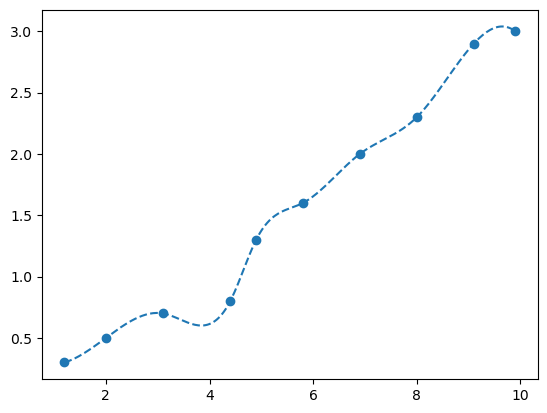

 linear


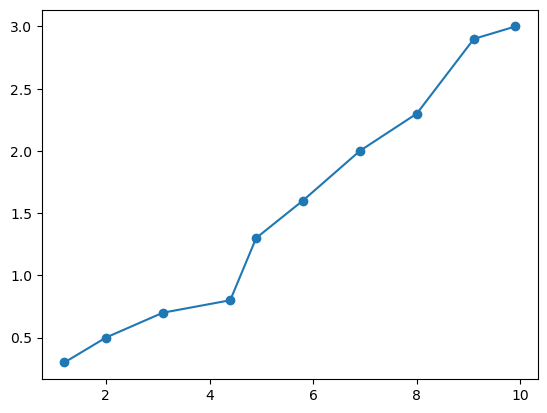

In [39]:
# session quiz 7.6 
from scipy import interpolate as ip

x = np.array([1.2, 2.0, 3.1, 4.4, 4.9, 5.8, 6.9, 8.0, 9.1, 9.9])
y = np.array([0.3, 0.5, 0.7, 0.8, 1.3, 1.6, 2.0, 2.3, 2.9, 3.0])
f = ip.interp1d(x, y, kind='cubic')

newx = np.linspace(1.2,9.9,250)
newy = f(newx)
plt.plot(newx, newy, linestyle = '--')
plt.scatter(x, y)
plt.show()
# it's so much faster and so much smoother. It's wayyy better

class Interpolation:
    def __init__(self, x, y):
        self.x = x
        self.y = y
        
    def linear(self):
        f = ip.interp1d(self.x, self.y, kind='linear')
        newx = np.linspace(min(self.x), max(self.x), 250)
        newy = f(newx)
        return newx, newy
    def polynomial(self):
        f = ip.interp1d(self.x, self.y, kind='quadratic')
        newx = np.linspace(min(self.x), max(self.x), 250)
        newy = f(newx)
        return newx, f(newx)
    def spline(self):
        f = ip.interp1d(self.x, self.y, kind='cubic')
        newx = np.linspace(min(self.x), max(self.x), 250)
        newy = f(newx)
        return newx, newy
a  = input()
if a == 'spline':
    newx, newy = Interpolation(x, y).spline()
    plt.plot(newx, newy)
if a == 'polynomial': 
    newx, newy = Interpolation(x, y).polynomial()
    plt.plot(newx, newy)
if a == 'linear':
    newx, newy = Interpolation(x, y).linear()
plt.plot(newx, newy)
plt.scatter(x, y)

plt.show()

method =  spline


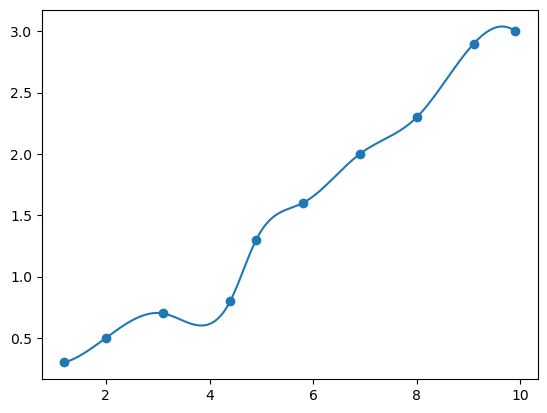

Enter X:  5.3


Y = 1.507226189773382


In [71]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import interpolate as ip

class Interpolation:
    def __init__(self, x, y):
        self.x = x
        self.y = y

    def linear(self):
        f = ip.interp1d(self.x, self.y, kind='linear')
        newx = np.linspace(min(self.x), max(self.x), 250)
        return newx, f(newx)

    def polynomial(self):
        f = ip.interp1d(self.x, self.y, kind='quadratic')
        newx = np.linspace(min(self.x), max(self.x), 250)
        return newx, f(newx)

    def spline(self):
        f = ip.interp1d(self.x, self.y, kind='cubic')
        newx = np.linspace(min(self.x), max(self.x), 250)
        return newx, f(newx)
    def value(self, X, method):
        if method == 'linear':
            f = ip.interp1d(self.x, self.y, kind='linear')
        elif method == 'polynomial':
            f = ip.interp1d(self.x, self.y, kind='quadratic')
        elif method == 'spline':
            f = ip.interp1d(self.x, self.y, kind='cubic')
        return float(f(X))
x = np.array([1.2, 2.0, 3.1, 4.4, 4.9, 5.8, 6.9, 8.0, 9.1, 9.9])
y = np.array([0.3, 0.5, 0.7, 0.8, 1.3, 1.6, 2.0, 2.3, 2.9, 3.0])

interp = Interpolation(x, y)

method = input("method = ")

if method == 'linear':
    newx, newy = interp.linear()
elif method == 'polynomial':
    newx, newy = interp.polynomial()
elif method == 'spline':
    newx, newy = interp.spline()
    
plt.plot(newx, newy)
plt.scatter(x, y)
plt.show()

X = float(input("Enter X: "))
print("Y =", interp.value(X, method))

In [72]:
# session quiz 7.7
import numpy as np

def bilinearIP(I, col, row): # Make it X, Y compatible
    '''I is a two dimensional array and iF,jF is the position at
       which we want to interpolate. 'iF' must be bigger or equal to 0 and
       smaller than the highest index of I in i. The same applies for jF'''
    rowlen, collen= I.shape
    i = int(row)
    j = int(col)
    if row - i == 0 and col - j == 0:  # Falls exactly on a gridpoint
        return I[i,j]

    inbounds = (0 <= j <= collen-1) and (0 <= i <= rowlen-1)
    if not inbounds:
        Iintp = None
    else:
        mu =  row - i
        Lambda = col - j
        # If we are at the last pixel at the right or bottom, then there
        # is not a neighbour, so we take the pixel itself as the neighbour
        I0 = I[i,j]
        I1 = I[i,min(j+1,collen-1)]
        I2 = I[min(i+1,rowlen-1),j]
        I3 = I[min(i+1,rowlen-1),min(j+1,collen-1)]
        Iintp = (1-Lambda)*(1-mu)*I0 + Lambda*(1-mu)*I1 + mu*(1-Lambda)*I2 + Lambda*mu*I3
    return(Iintp)

I = np.array([[2.0,4.1], [2.5,3.8]])
x = 0.2
y = 0.7
print('interpolated intensity =', bilinearIP(I, y, x))

interpolated intensity = 3.4579999999999993


sq = (array([64.1323357, 69.9380315]), 1)
fit = [64.13234248 69.9377803 ]


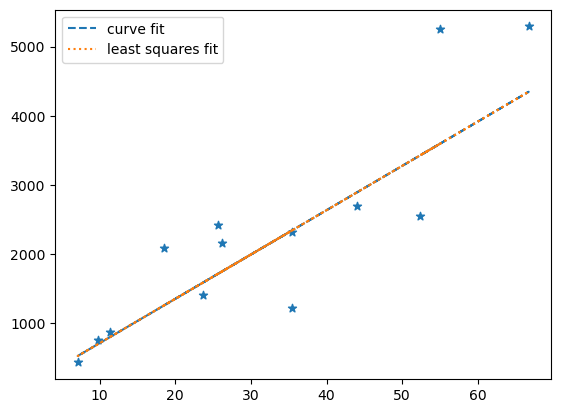

In [118]:
# session quiz 7.10
from scipy.optimize import leastsq, curve_fit
import matplotlib.pyplot as plt

data = [
   18.49,     2094.75,    0.3,           100,
   35.48,     2320.87,    2.2,           120,
   35.48,     1224.9,     3.0,           80,
   11.34,     872.13,     1.2,           80,
   7.12,      432.2,      0.4,           70,
   9.82,      751,        0.3,           75,
   23.66,     1410,       2.3,           70,
   44,        2700,       4.0,           110,
   66.7,      5292,       5.3,           120,
   52.4,      2550,       5.2,           100,
   55,        5253,       6.1,           150,
   25.6,      2419,       3.2,           110,
   26.19,     2158,       2.8,           110
]

# data slicing
v = np.array(data[1::4])
d = np.array(data[0::4])
err_v = np.array(data[3::4])
err_d = np.array(data[2::4])

# leastsq
def f(d, a, b):
    return a*d + b

def residuals(guess, d, v, err_v):
    a, b = guess
    return (v - f(d, a, b)) / err_v

guess = [64, 69]
sq = leastsq(residuals, guess[:], args = (d, v, err_v))
print('sq =', sq)

# curve_fit
fit, error = curve_fit(f, d, v, sigma = err_v, absolute_sigma = True)
print('fit =', fit)

# plotting
plt.plot(d, fit[0] * d + fit[1], linestyle = '--', label = 'curve fit')
plt.plot(d, sq[0][0] * d + sq[0][1], linestyle = ':', label = 'least squares fit')
plt.scatter(d, v, marker = '*')
plt.legend()
plt.show()